In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import gurobipy as gp
from gurobipy import GRB

pd.set_option('display.max_columns', None)

customers_df = pd.read_excel("/Users/serhandulger/Desktop/MODELING_AND_OPTIMIZATION/ev_customers_df_cleaned_proportional.xlsx")

distance_matrix_df = pd.read_csv("/Users/serhandulger/Desktop/MODELING_AND_OPTIMIZATION/ev_distance_matrix_df.csv")

def checking_df(df):
    print("### FIRST FIVE ROWS ###")
    print(df.head())
    print("### DATAFRAME ROWS/ FEATURES COUNT ###")
    print(df.shape)
    print("### DATAFRAME FEATURES DATA TYPES ###")
    print(df.dtypes)
    print("### NULL VALUES COUNT ###")
    print(df.isnull().sum())

checking_df(customers_df)

### FIRST FIVE ROWS ###
   request_id     segment    x_km    y_km  traffic_multiplier  kwh_needed  \
0         196  competitor   7.988  24.935                 1.3        19.7   
1          94  competitor   8.135  13.869                 1.0        14.1   
2          21  competitor  12.097  24.560                 1.6        10.8   
3         130  competitor  22.900  23.174                 1.3        14.4   
4         188  competitor  22.438  16.697                 1.6        19.2   

   service_time_min  distance_from_depot_km  repurchase_prob  \
0         30.984848                  12.160              NaN   
1         21.085859                   6.958              NaN   
2         15.252525                   9.991              NaN   
3         21.616162                  11.368              NaN   
4         30.101010                   7.629              NaN   

   acquisition_prob  ltv  brand_premium  
0             0.224  NaN           1.47  
1             0.363  NaN           1.46  
2 

In [2]:
customers_df.head(3)

,request_id,segment,x_km,y_km,traffic_multiplier,kwh_needed,service_time_min,distance_from_depot_km,repurchase_prob,acquisition_prob,ltv,brand_premium
0,196,competitor,7.988,24.935,1.3,19.7,30.984848,12.160,NaN,0.224,NaN,1.47
1,94,competitor,8.135,13.869,1.0,14.1,21.085859,6.958,NaN,0.363,NaN,1.46
2,21,competitor,12.097,24.560,1.6,10.8,15.252525,9.991,NaN,0.186,NaN,1.41


In [3]:
customers_df[customers_df["segment"]=="competitor"].head(3)

,request_id,segment,x_km,y_km,traffic_multiplier,kwh_needed,service_time_min,distance_from_depot_km,repurchase_prob,acquisition_prob,ltv,brand_premium
0,196,competitor,7.988,24.935,1.3,19.7,30.984848,12.160,NaN,0.224,NaN,1.47
1,94,competitor,8.135,13.869,1.0,14.1,21.085859,6.958,NaN,0.363,NaN,1.46
2,21,competitor,12.097,24.560,1.6,10.8,15.252525,9.991,NaN,0.186,NaN,1.41


In [4]:
df = customers_df.copy()

## Model preprocessing: standardizing missing values to ensure stable value score calculations
df["repurchase_prob"] = df["repurchase_prob"].fillna(0)
df["ltv"] = df["ltv"].fillna(0)
df["acquisition_prob"] = df["acquisition_prob"].fillna(0)

########################################################################################################################

## Segment-based base pricing (fixed to isolate discount and premium effects for now - it may change depends on the business rules)
df["base_price"] = np.where(df["segment"].eq("own"), 0.50, 0.50)

########################################################################################################################

## LTV-based discount for own customers (higher LTV implies higher discount)
disc_max = 0.25  # maximum discount rate for own customers
df["own_discount"] = np.where(df["segment"].eq("own"),disc_max * (df["ltv"] / 100.0),0.0)

## Brand-premium-based surcharge for competitor customers
prem_max = 0.30  # premium intensity parameter
df["comp_premium"] = np.where(df["segment"].eq("competitor"),prem_max * (df["brand_premium"] - 1.0),0.0)

########################################################################################################################

## Adjusted price per kWh after applying discounts and premiums
df["price_adj"] = df["base_price"] * (1 - df["own_discount"]) * (1 + df["comp_premium"])

## Adjusted revenue computation: kWh demand multiplied by adjusted price
df["revenue_adj"] = (df["kwh_needed"] * df["price_adj"]).round(2)

df[["request_id", "segment", "ltv", "brand_premium","base_price", "own_discount", "comp_premium","price_adj", "kwh_needed", "revenue_adj"]].head(5)

,request_id,segment,ltv,brand_premium,base_price,own_discount,comp_premium,price_adj,kwh_needed,revenue_adj
0,196,competitor,0.0,1.47,0.5,0.0,0.141,0.5705,19.7,11.24
1,94,competitor,0.0,1.46,0.5,0.0,0.138,0.5690,14.1,8.02
2,21,competitor,0.0,1.41,0.5,0.0,0.123,0.5615,10.8,6.06
3,130,competitor,0.0,1.40,0.5,0.0,0.120,0.5600,14.4,8.06
4,188,competitor,0.0,1.39,0.5,0.0,0.117,0.5585,19.2,10.72


### Pricing and Revenue Adjustment – Summary

This preprocessing step defines a pricing structure that reflects different business objectives
for own and competitor-brand customers.

- A **fixed base price of 0.50 per kWh** is applied to all customers to keep the baseline tariff
  constant while allowing controlled price variation through adjustments.

- **Own customers** receive loyalty-based discounts driven by Lifetime Value (LTV):
  - The discount increases linearly with LTV.
  - The maximum discount is capped at **25%**, prioritizing long-term customer retention.

- **Competitor-brand customers** are subject to a brand premium:
  - The premium reflects short-term revenue opportunities.
  - The surcharge intensity is capped at **30%** and depends on the brand premium factor. (fluctuates between 1,01-1,47)

- The final price per kWh varies across customers due to these discounts and premiums, even
  though the base price is fixed.

- Adjusted revenue is computed as the product of energy demand (kWh) and the adjusted price,
  and will later be used as an input to the value score in the knapsack model.


In [5]:
## Short-term net contribution: adjusted revenue minus travel cost
cost_per_km = 0.35  # operational cost per kilometer (labor, energy, logistics)
df["travel_cost"] = df["distance_from_depot_km"] * cost_per_km

df["short_term_net"] = df["revenue_adj"] - df["travel_cost"]
## Negative values indicate requests that are unprofitable in the short run and require further inspection

########################################################################################################################

## Long-term component for own customers: loyalty and repurchase effect
## Only applicable to own customers
df["long_term_own"] = np.where(df["segment"] == "own",df["ltv"] * df["repurchase_prob"],0.0)

########################################################################################################################

## Long-term component for competitor customers: acquisition potential
expected_ltv_if_acquired = 60.0  # assumed average LTV after successful acquisition

df["long_term_comp"] = np.where(df["segment"] == "competitor",df["acquisition_prob"] * df["brand_premium"] * expected_ltv_if_acquired,0.0)

df[["request_id", "ltv", "segment", "service_time_min","price_adj", "revenue_adj", "kwh_needed","travel_cost", "short_term_net","long_term_own", "long_term_comp", "service_time_min"]].head(5)

,request_id,ltv,segment,service_time_min,price_adj,revenue_adj,kwh_needed,travel_cost,short_term_net,long_term_own,long_term_comp,service_time_min
0,196,0.0,competitor,30.984848,0.5705,11.24,19.7,4.25600,6.98400,0.0,19.7568,30.984848
1,94,0.0,competitor,21.085859,0.5690,8.02,14.1,2.43530,5.58470,0.0,31.7988,21.085859
2,21,0.0,competitor,15.252525,0.5615,6.06,10.8,3.49685,2.56315,0.0,15.7356,15.252525
3,130,0.0,competitor,21.616162,0.5600,8.06,14.4,3.97880,4.08120,0.0,26.5440,21.616162
4,188,0.0,competitor,30.101010,0.5585,10.72,19.2,2.67015,8.04985,0.0,28.1058,30.101010


In [6]:
########################################################################################################################

### ADDITIONAL NOTES ###

## Externally assumed parameters used in this step:
## - cost_per_km
## - repurchase_prob (customer-specific)
## - acquisition_prob
## - expected_ltv_if_acquired
## - traffic multiplier (introduced in the next block)

########################################################################################################################

### Value Score Components – Short-Term and Long-Term Logic

In this step, each service request’s value is decomposed into short-term and long-term components
to balance immediate profitability with strategic customer value.

- **Short-term net contribution (`short_term_net`):**  
  This component represents the immediate, request-specific economic contribution of serving a customer on the given day. For each request, the firm charges a customer-specific adjusted price (revenue_adj), which already reflects pricing differences across customer       segments (e.g., premium pricing for competitor-brand customers and discounted pricing for own customers based on loyalty considerations).

- **Long-term value for own customers (`long_term_own`):**  
  For own customers, long-term value reflects loyalty and repeat behavior. It is modeled as the
  product of Lifetime Value (LTV) and repurchase probability, ensuring that high-value and highly
  loyal customers receive higher priority in value score.

- **Long-term value for competitor customers (`long_term_comp`):**  
  For competitor-brand customers, long-term value represents acquisition potential rather than
  loyalty. It is calculated using acquisition probability, brand premium factor, and an assumed
  expected LTV after successful acquisition. This allows the model to favor strategically valuable
  competitor customers even if short-term profitability is limited.

- **Modeling assumptions:**  
  Key parameters such as travel cost per kilometer, repurchase probability, acquisition probability,
  and expected LTV after acquisition are treated as exogenous inputs to keep the model interpretable.

These components jointly form the foundation of the value score used as the objective coefficient
in the knapsack-based selection model.


In [7]:
# -----------------------------
# VALUE SCORE (input to the knapsack objective)
# -----------------------------

## Weight of short-term net contribution (dominant component)
w_short = 1.0

## Weight of long-term loyalty value for own customers
## Scaled down to reflect future (non-immediate) monetary impact
w_own = 0.20

## Weight of long-term acquisition value for competitor customers
## Can be set higher or lower depending on strategic priorities
w_comp = 0.20

## Aggregated value score to be maximized by the knapsack model
df["value_score"] = (w_short * df["short_term_net"]+ w_own * df["long_term_own"]+ w_comp * df["long_term_comp"])

## Enforce non-negativity to avoid selecting low-value or loss-making requests
df["value_score"] = df["value_score"].clip(lower=0)

df[["request_id", "ltv", "segment","short_term_net", "repurchase_prob","long_term_own", "long_term_comp","value_score"]].head(5)

,request_id,ltv,segment,short_term_net,repurchase_prob,long_term_own,long_term_comp,value_score
0,196,0.0,competitor,6.98400,0.0,0.0,19.7568,10.93536
1,94,0.0,competitor,5.58470,0.0,0.0,31.7988,11.94446
2,21,0.0,competitor,2.56315,0.0,0.0,15.7356,5.71027
3,130,0.0,competitor,4.08120,0.0,0.0,26.5440,9.39000
4,188,0.0,competitor,8.04985,0.0,0.0,28.1058,13.67101


### Value Score Construction – Objective Function Input

At this stage, the value score framework is designed to be business-configurable.
Decision-makers can adjust the relative importance of short-term profitability versus long-term
strategic objectives by tuning the weight parameters. For example, management may choose to
prioritize long-term customer acquisition or loyalty over immediate profit in certain periods,
which would directly affect the request selection outcome of the optimization model.

In this step, all previously computed short-term and long-term components are aggregated into a
single scalar value score. This score represents the overall attractiveness of serving a request
and is used as the objective coefficient in the knapsack selection model.

- **Weighted structure:**  
  The value score is constructed as a weighted sum of short-term and long-term components,
  allowing explicit control over the trade-off between immediate profitability and strategic value.

- **Short-term weight (`w_short`):**  
  The short-term net contribution is assigned the highest weight, ensuring that immediate
  operational profitability forms the backbone of the value score.

- **Own-customer long-term weight (`w_own`):**  
  The long-term loyalty value of own customers is assigned a smaller weight, reflecting that
  this component represents future potential rather than immediate cash flow.

- **Competitor-customer long-term weight (`w_comp`):**  
  The long-term acquisition value of competitor customers is weighted separately. Its magnitude
  can be adjusted to reflect how strategically important customer acquisition is relative to
  loyalty retention.

- **Non-negativity constraint:**  
  Negative value scores are clipped to zero to prevent the knapsack model from selecting requests
  that are unattractive from an overall value perspective.

The resulting value score provides a consistent and interpretable objective input for the
knapsack-based request selection stage.


In [8]:
# DEPOT → CUSTOMER TRAVEL TIME (minutes)

## Baseline assumption: average urban speed ≈ 40 km/h
## 60 minutes / 40 km ≈ 1.5 minutes per km (traffic-free reference)
MIN_PER_KM = 1.5  # minutes required to travel 1 km under normal conditions

## One-way travel time from depot to customer (minutes)
df["travel_time_min"] = (df["distance_from_depot_km"] * MIN_PER_KM * df["traffic_multiplier"])

# TOTAL CUSTOMER TIME (SERVICE + TRAVEL)

## service_time_min: on-site service duration
## travel_time_min : travel time from depot
## Their sum represents the true operational time cost per request
df["total_time_min"] = (df["service_time_min"] + df["travel_time_min"])

In [9]:
df.head()

,request_id,segment,x_km,y_km,traffic_multiplier,kwh_needed,service_time_min,distance_from_depot_km,repurchase_prob,acquisition_prob,ltv,brand_premium,base_price,own_discount,comp_premium,price_adj,revenue_adj,travel_cost,short_term_net,long_term_own,long_term_comp,value_score,travel_time_min,total_time_min
0,196,competitor,7.988,24.935,1.3,19.7,30.984848,12.160,0.0,0.224,0.0,1.47,0.5,0.0,0.141,0.5705,11.24,4.25600,6.98400,0.0,19.7568,10.93536,23.7120,54.696848
1,94,competitor,8.135,13.869,1.0,14.1,21.085859,6.958,0.0,0.363,0.0,1.46,0.5,0.0,0.138,0.5690,8.02,2.43530,5.58470,0.0,31.7988,11.94446,10.4370,31.522859
2,21,competitor,12.097,24.560,1.6,10.8,15.252525,9.991,0.0,0.186,0.0,1.41,0.5,0.0,0.123,0.5615,6.06,3.49685,2.56315,0.0,15.7356,5.71027,23.9784,39.230925
3,130,competitor,22.900,23.174,1.3,14.4,21.616162,11.368,0.0,0.316,0.0,1.40,0.5,0.0,0.120,0.5600,8.06,3.97880,4.08120,0.0,26.5440,9.39000,22.1676,43.783762
4,188,competitor,22.438,16.697,1.6,19.2,30.101010,7.629,0.0,0.337,0.0,1.39,0.5,0.0,0.117,0.5585,10.72,2.67015,8.04985,0.0,28.1058,13.67101,18.3096,48.410610


### Travel Time and Total Service Time Construction

This step translates geographic distance into operational time and constructs the total time
required to serve each customer request. These time measures will later be used as key capacity
constraints in the knapsack selection model.

- **Baseline travel speed assumption:**  
  A reference average city speed of approximately 40 km/h is assumed, corresponding to
  1.5 minutes per kilometer under normal traffic conditions. This serves as a baseline for
  travel time estimation.

- **Traffic adjustment:**  
  Real-world traffic conditions are incorporated through a traffic multiplier feature that
  is provided as an exogenous input. This feature reflects the typical congestion level on the
  route from the depot to each customer location (e.g., peak-hour density, historically busy
  corridors). By scaling the baseline travel time, the multiplier allows travel durations to
  vary across requests while preserving a consistent underlying speed assumption.

- **One-way travel time from depot:**  
  Travel time is computed as the one-way time required to reach the customer from the depot.
  This simplification keeps the selection model tractable while still capturing geographic
  dispersion effects.

- **Total time consumption per request:**  
  The total time required to serve a request is defined as the sum of on-site service time and
  travel time. This represents the actual time budget consumed by the vehicle and driver when
  fulfilling a request.

The resulting total time variable is later used to enforce daily working-time constraints
within the optimization model.


## Model Variables

The optimization model is constructed using the following variables:

- **Value Score (`value_score`)**  
   The value score is constructed as a weighted aggregation of short-term and long-term components.
   The relative importance of these components is controlled through predefined weights, which
   reflect the strategic priorities of the decision maker.

   By adjusting these weights, the model can represent different business objectives, such as
   prioritizing immediate profitability versus long-term customer value. Importantly, these
   weights are treated as exogenous parameters that are fixed prior to optimization and are not
   decision variables within the model itself.

- **Total Service Time (`total_time_min`)**  
  This variable denotes the total time (in minutes) required to serve a customer.  
  It is calculated by normalizing the service duration with traffic conditions, ensuring that the time requirement reflects real-world operational conditions rather than only the nominal service time.

- **Energy Requirement (`kwh_needed`)**  
   Energy Requirement (kwh_needed)  
   This variable represents the amount of energy (in kilowatt-hours) requested by the customer
   and delivered during the service. It reflects the customer’s charging demand.

   In the optimization model, this variable is used to enforce the daily energy delivery capacity
   of the fleet, ensuring that the total energy supplied across all selected requests does not
   exceed the available kWh capacity.

## Operational Constraints

The optimization problem is subject to the following operational constraints:

1. **Working Time Constraint**  
   A vehicle has a daily working time capacity of **460 minutes**.  
   This capacity is derived from working hours between **08:00 and 17:00**, with **20-minute breaks every two hours** deducted from the total available time:

2. **Energy Capacity Constraint**  
   Each vehicle can distribute a maximum of **225 kWh of energy per day**:


These constraints ensure that the selected set of customers for each vehicle is feasible with respect to daily working time and energy availability.

In [10]:
####################
# MODELLING
####################

In [11]:
ids = df["request_id"].tolist()

value   = dict(zip(df["request_id"], df["value_score"]))
service = dict(zip(df["request_id"], df["total_time_min"]))
energy  = dict(zip(df["request_id"], df["kwh_needed"]))

# Single-vehicle daily capacities
S_max = 460   # minutes
E_max = 225   # kWh

# -----------------------------
# Scenario settings
# -----------------------------
K_list = list(range(5, 31)) 
exact = True  # True: ==K, False: <=K

results = []

for K in K_list:
    m = gp.Model(f"knapsack_K{K}")
    m.setParam("OutputFlag", 0)  # keep silent

    x = m.addVars(ids, vtype=GRB.BINARY, name="x")

    # Objective: maximize total value_score
    m.setObjective(gp.quicksum(value[i] * x[i] for i in ids), GRB.MAXIMIZE)

    # Quota constraint: select exactly K (or at most K)
    if exact:
        m.addConstr(gp.quicksum(x[i] for i in ids) == K, name="quota_exact")
    else:
        m.addConstr(gp.quicksum(x[i] for i in ids) <= K, name="quota_max")

    # Capacity constraints
    m.addConstr(gp.quicksum(service[i] * x[i] for i in ids) <= S_max, name="time_budget")
    m.addConstr(gp.quicksum(energy[i]  * x[i] for i in ids) <= E_max, name="energy_budget")

    m.optimize()

    feasible = (m.SolCount > 0)

    if feasible:
        selected_ids = [i for i in ids if x[i].X > 0.5]
        sel_n = len(selected_ids)

        total_time   = sum(service[i] for i in selected_ids)
        total_energy = sum(energy[i]  for i in selected_ids)
        total_value  = sum(value[i]   for i in selected_ids)

        avg_time   = total_time / sel_n if sel_n > 0 else 0
        avg_energy = total_energy / sel_n if sel_n > 0 else 0

        results.append({
            "K_target": K,
            "feasible": True,
            "selected_n": sel_n,
            "total_value_score": total_value,
            "total_time_min": total_time,
            "time_util": total_time / S_max,
            "total_energy_kwh": total_energy,
            "energy_util": total_energy / E_max,
            "avg_time_min": avg_time,
            "avg_energy_kwh": avg_energy,
        })
    else:
        results.append({
            "K_target": K,
            "feasible": False,
            "selected_n": 0,
            "total_value_score": None,
            "total_time_min": None,
            "time_util": None,
            "total_energy_kwh": None,
            "energy_util": None,
            "avg_time_min": None,
            "avg_energy_kwh": None,
        })

res_df = pd.DataFrame(results)

print(res_df.to_string(index=False))

if exact:
    feasible_K = res_df.loc[res_df["feasible"], "K_target"]
    if len(feasible_K) > 0:
        print("\nMax feasible K (exact selection):", int(feasible_K.max()))
    else:
        print("\nNo feasible K found under exact selection.")
else:
    print("\nMax selected_n under <=K:", int(res_df["selected_n"].max()))


Restricted license - for non-production use only - expires 2026-11-23
 K_target  feasible  selected_n  total_value_score  total_time_min  time_util  total_energy_kwh  energy_util  avg_time_min  avg_energy_kwh
        5      True           5           97.09901      243.984863   0.530402             108.8     0.483556     48.796973       21.760000
        6      True           6          115.72332      281.430737   0.611806             124.4     0.552889     46.905123       20.733333
        7      True           7          134.01697      336.645945   0.731839             146.7     0.652000     48.092278       20.957143
        8      True           8          151.92767      372.979351   0.810825             162.2     0.720889     46.622419       20.275000
        9      True           9          169.49858      411.534740   0.894641             179.3     0.796889     45.726082       19.922222
       10      True          10          186.34440      445.529598   0.968543             193.4 

## Single Vehicle – Customer Count Scenarios

The table shows how the model’s selected customer set changes as the **target number of customers (K_target)** increases, and how this impacts **total value (value_score)**, **time usage**, and **energy usage** under fixed daily capacities.

- **K_target:** Scenario value representing the targeted number of customers to serve that day.
- **feasible:** Whether the scenario is achievable under daily **time (460 min)** and **energy (225 kWh)** capacities.
- **selected_n:** Number of selected customers (typically equals K_target when feasible).
- **total_value_score:** Total value score of the selected set (the overall objective performance).
- **total_time_min / time_util:** Total time consumed by the selected set and its utilization of the 460-min capacity.
- **total_energy_kwh / energy_util:** Total kWh demand of the selected set and its utilization of the 225-kWh capacity.
- **avg_time_min / avg_energy_kwh:** Average time and average kWh per selected customer (a proxy for the “profile/size” of selected jobs).

### Key insights from the results
- **Maximum serviceable customer count:** The table indicates feasibility up to **K=17**, while **K=18 and above** are infeasible.  
  --> Under these assumptions, the single vehicle can serve **at most 17 customers** in a day.

- **The binding bottleneck is time:** As K increases, **time_util quickly approaches 1.00** (nearly full utilization after ~11).  
  Meanwhile, **energy_util remains noticeably below 1.00**.  
  --> The limiting factor here is **total operational time (service + travel)** rather than energy capacity.

- **The selected request profile shifts as K increases:**  
  Both **avg_time_min** and **avg_energy_kwh** decrease with larger K.  
  --> To fit more customers into a fixed day, the model tends to select **shorter** and **lower-energy** requests.

- **Peak total performance (best total score):**  
  **total_value_score peaks around K=13** and then declines for larger K.  
  --> Beyond this point, fitting additional customers requires including lower-contribution requests, which reduces the total score.

### Focused Metrics
- **Feasibility** → `feasible`
- **Maximum achievable customer count** → largest feasible `K_target` (17 here)
- **Which constraint limits the operation** → `time_util` vs `energy_util` (time here)
- **Best overall performance level** → `total_value_score` (around 13 here)

In [12]:
ids = df["request_id"].tolist()

value   = dict(zip(df["request_id"], df["value_score"]))
time_c  = dict(zip(df["request_id"], df["total_time_min"]))   # total operational time
energy  = dict(zip(df["request_id"], df["kwh_needed"]))

K = 13
S_max = 460   # minutes (daily time capacity)
E_max = 225   # kWh (daily energy capacity)

m = gp.Model("knapsack_selection_K13")
m.setParam("OutputFlag", 1)

x = m.addVars(ids, vtype=GRB.BINARY, name="x")

# Objective: maximize total value score
m.setObjective(gp.quicksum(value[i] * x[i] for i in ids), GRB.MAXIMIZE)

# Constraints
m.addConstr(gp.quicksum(x[i] for i in ids) == K, name="quota_exact_K")
m.addConstr(gp.quicksum(time_c[i] * x[i] for i in ids) <= S_max, name="time_budget")
m.addConstr(gp.quicksum(energy[i] * x[i] for i in ids) <= E_max, name="energy_budget")

m.optimize()

print("Status:", m.Status, "SolCount:", m.SolCount)

if m.SolCount > 0:
    selected_ids = [i for i in ids if x[i].X > 0.5]

    total_time = sum(time_c[i] for i in selected_ids)
    total_energy = sum(energy[i] for i in selected_ids)
    total_value = sum(value[i] for i in selected_ids)

    print("Selected:", len(selected_ids))
    print("Total time (min):", total_time, "/", S_max)
    print("Total energy (kWh):", total_energy, "/", E_max)
    print("Total value_score:", total_value)

    # Mark selection and create routing input
    df["selected"] = df["request_id"].isin(selected_ids).astype(int)
    selected_df = df[df["selected"] == 1].copy()   # <-- THIS is what you pass to TSP/VRP
else:
    print("No solution found (constraints may be too tight for this K).")
    selected_df = df.iloc[0:0].copy()


Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[rosetta2] - Darwin 24.6.0 24G222)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 3 rows, 200 columns and 600 nonzeros
Model fingerprint: 0xcc427935
Variable types: 0 continuous, 200 integer (200 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+01]
  Objective range  [2e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+01, 5e+02]
Found heuristic solution: objective 119.1901000
Presolve time: 0.00s
Presolved: 3 rows, 200 columns, 598 nonzeros
Variable types: 0 continuous, 200 integer (200 binary)

Root relaxation: objective 2.096675e+02, 3 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0  209.66746    0    2  119.19010  209.66746  75.9%  

## Summary for Knapsack Output (k=13 selected)

In this cell, the knapsack-based selection model is solved for the **K=13** scenario. The goal is to select **13 service requests** that maximize the **total value_score** while satisfying the daily operational capacity constraints (**460 minutes** of total time and **225 kWh** of energy). After optimization, the selected set is stored as `selected_ids` / `selected_df`, which will be used as the direct input to the project’s second stage, **routing (TSP/VRP)**. The reported totals (time usage, energy usage, and total value_score) provide a clear summary of how tightly the selected solution utilizes the available capacities under the given constraints.

In [13]:
df["selected"] = df["request_id"].isin(selected_ids)

selected_df     = df[df["selected"]].copy()
not_selected_df = df[~df["selected"]].copy()

In [14]:
selected_df.head(50)

,request_id,segment,x_km,y_km,traffic_multiplier,kwh_needed,service_time_min,distance_from_depot_km,repurchase_prob,acquisition_prob,ltv,brand_premium,base_price,own_discount,comp_premium,price_adj,revenue_adj,travel_cost,short_term_net,long_term_own,long_term_comp,value_score,travel_time_min,total_time_min,selected
9,106,competitor,8.338,19.756,1.0,12.2,17.727273,8.185,0.000,0.617,0.0,1.32,0.5,0.00000,0.096,0.548000,6.69,2.86475,3.82525,0.0000,48.8664,13.59853,12.2775,30.004773,True
54,85,competitor,20.179,11.687,1.3,13.9,20.732323,6.148,0.000,0.623,0.0,1.11,0.5,0.00000,0.033,0.516500,7.18,2.15180,5.02820,0.0000,41.4918,13.32656,11.9886,32.720923,True
95,4,own,21.020,18.473,1.0,22.0,35.050505,6.950,0.778,0.000,100.0,NaN,0.5,0.25000,0.000,0.375000,8.25,2.43250,5.81750,77.8000,0.0000,21.37750,10.4250,45.475505,True
102,14,own,10.265,10.621,1.3,11.8,17.020202,6.450,0.780,0.000,67.9,NaN,0.5,0.16975,0.000,0.415125,4.90,2.25750,2.64250,52.9620,0.0000,13.23490,12.5775,29.597702,True
123,46,own,7.984,9.205,1.6,12.4,18.080808,9.100,0.938,0.000,78.2,NaN,0.5,0.19550,0.000,0.402250,4.99,3.18500,1.80500,73.3516,0.0000,16.47532,21.8400,39.920808,True
132,58,own,21.440,21.485,1.0,15.6,23.737374,9.139,0.898,0.000,87.6,NaN,0.5,0.21900,0.000,0.390500,6.09,3.19865,2.89135,78.6648,0.0000,18.62431,13.7085,37.445874,True
134,63,own,20.852,21.272,1.0,16.7,25.681818,8.578,0.855,0.000,92.6,NaN,0.5,0.23150,0.000,0.384250,6.42,3.00230,3.41770,79.1730,0.0000,19.25230,12.8670,38.548818,True
166,126,own,12.032,10.583,1.6,15.5,23.560606,5.322,0.938,0.000,71.5,NaN,0.5,0.17875,0.000,0.410625,6.36,1.86270,4.49730,67.0670,0.0000,17.91070,12.7728,36.333406,True
169,138,own,21.187,12.095,1.6,11.1,15.782828,6.835,0.608,0.000,97.1,NaN,0.5,0.24275,0.000,0.378625,4.20,2.39225,1.80775,59.0368,0.0000,13.61511,16.4040,32.186828,True
174,150,own,9.157,9.373,1.0,17.1,26.388889,8.111,0.806,0.000,84.8,NaN,0.5,0.21200,0.000,0.394000,6.74,2.83885,3.90115,68.3488,0.0000,17.57091,12.1665,38.555389,True


In [15]:
####################
# DISTANCE MATRIX
###################

## Distance Matrix Data Description

The file (`ev_distance_matrix_df.csv`) provides travel information between the depot and all
customer nodes as a complete directed network. Rather than being stored as a square NxN matrix,
the data is represented in a long-format edge list, where each row corresponds to a directed
movement from an origin node to a destination node (from_node_id → to_node_id).

The dataset includes:
- depot → customer links,
- customer → customer links,
- and customer → depot links,

allowing full pairwise travel distances and times to be captured.

- from_node_id: Origin node (starting point)
- to_node_id: Destination node (arrival point)
- distance_km: Travel distance between the two nodes (kilometers)
- travel_time_min: Travel time between the two nodes (minutes)

This dataset is used in the project’s second stage (routing). After the knapsack model selects
the set of customer requests to serve, the distance matrix is filtered to retain only the links
among the depot and the selected customers. The resulting reduced network forms the core input
for the routing analysis.

This filtered distance matrix is then used consistently across:
(i) the single-vehicle TSP baseline, where customer-to-customer distances determine the optimal
visit order, and
(ii) the multi-vehicle VRP extension using the Clarke–Wright Savings heuristic, where savings are
computed based on customer-to-customer links relative to separate depot returns.


In [16]:
distance_matrix_df.head()

,from_node_id,to_node_id,distance_km,travel_time_min
0,0,1,11.735,26.99
1,0,2,3.938,10.24
2,0,3,10.803,24.85
3,0,4,6.950,15.98
4,0,5,10.157,26.41


In [17]:
distance_matrix_df.shape

(40200, 4)

Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[rosetta2] - Darwin 24.6.0 24G222)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 225 rows, 210 columns and 873 nonzeros
Model fingerprint: 0x4e27e980
Variable types: 14 continuous, 196 integer (196 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 5e+01]
  Bounds range     [1e+00, 1e+01]
  RHS range        [1e+00, 1e+01]
Presolve removed 41 rows and 15 columns
Presolve time: 0.00s
Presolved: 184 rows, 195 columns, 1668 nonzeros
Variable types: 13 continuous, 182 integer (182 binary)
Found heuristic solution: objective 338.2600000
Found heuristic solution: objective 303.5700000

Root relaxation: objective 9.601313e+01, 60 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent 

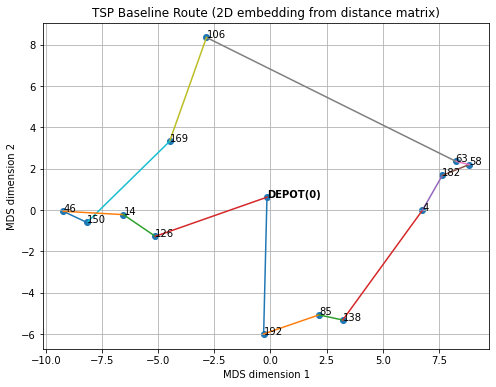

In [18]:
# =========================
# 0) INPUTS (already defined in your notebook)
# =========================
edges = distance_matrix_df  # <-- your existing edge list dataframe
selected_ids = selected_df["request_id"].tolist()  # knapsack result
DEPOT = 0  # change if your depot id is different

# Quick column check
needed_cols = {"from_node_id", "to_node_id", "distance_km", "travel_time_min"}
missing = needed_cols - set(edges.columns)
if missing:
    raise ValueError(f"distance_matrix_df is missing columns: {missing}")

# =========================
# 1) BUILD NODE SET (depot + selected customers)
# =========================
nodes = [DEPOT] + selected_ids
nodes = list(dict.fromkeys(nodes))  # unique
n = len(nodes)

node_to_idx = {node: idx for idx, node in enumerate(nodes)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# =========================
# 2) FILTER EDGE LIST TO SUBGRAPH
# =========================
sub = edges[edges["from_node_id"].isin(nodes) & edges["to_node_id"].isin(nodes)].copy()

expected = n * (n - 1)  # all directed pairs without diagonal
if len(sub) != expected:
    raise ValueError(
        f"Subgraph is incomplete: expected {expected} directed edges, found {len(sub)}.\n"
        f"Check DEPOT id, selected_ids mapping, and whether the edge list contains all pairs."
    )

# =========================
# 3) BUILD TIME & DIST MATRICES (n x n)
# =========================
time_mat = np.zeros((n, n), dtype=float)
dist_mat = np.zeros((n, n), dtype=float)

for r in sub.itertuples(index=False):
    i = node_to_idx[getattr(r, "from_node_id")]
    j = node_to_idx[getattr(r, "to_node_id")]
    time_mat[i, j] = float(getattr(r, "travel_time_min"))
    dist_mat[i, j] = float(getattr(r, "distance_km"))

np.fill_diagonal(time_mat, 0.0)
np.fill_diagonal(dist_mat, 0.0)

# =========================
# 4) SOLVE TSP (Exact, Gurobi) - Minimize total travel time
# =========================
m = gp.Model("TSP_baseline_single_vehicle")
m.setParam("OutputFlag", 1)

x = m.addVars(n, n, vtype=GRB.BINARY, name="x")

# No self arcs
for i in range(n):
    m.addConstr(x[i, i] == 0, name=f"no_self_{i}")

# Degree constraints
for i in range(n):
    m.addConstr(gp.quicksum(x[i, j] for j in range(n) if j != i) == 1, name=f"out_{i}")
    m.addConstr(gp.quicksum(x[j, i] for j in range(n) if j != i) == 1, name=f"in_{i}")

# MTZ subtour elimination
u = m.addVars(n, vtype=GRB.CONTINUOUS, lb=0, ub=n-1, name="u")
m.addConstr(u[0] == 0, name="u_depot")

for i in range(1, n):
    m.addConstr(u[i] >= 1, name=f"u_lb_{i}")
    m.addConstr(u[i] <= n-1, name=f"u_ub_{i}")

for i in range(1, n):
    for j in range(1, n):
        if i != j:
            m.addConstr(u[i] - u[j] + (n-1) * x[i, j] <= n-2, name=f"mtz_{i}_{j}")

m.setObjective(gp.quicksum(time_mat[i, j] * x[i, j] for i in range(n) for j in range(n)), GRB.MINIMIZE)
m.optimize()

if m.SolCount == 0:
    raise RuntimeError("TSP has no solution. (Unexpected if subgraph is complete.)")

# =========================
# 5) EXTRACT TOUR ORDER
# =========================
succ = {}
for i in range(n):
    for j in range(n):
        if x[i, j].X > 0.5:
            succ[i] = j

tour_idx = [0]
cur = 0
for _ in range(n - 1):
    cur = succ[cur]
    tour_idx.append(cur)
tour_idx.append(0)  # return depot

tour_nodes = [idx_to_node[i] for i in tour_idx]

total_time = sum(time_mat[a, b] for a, b in zip(tour_idx[:-1], tour_idx[1:]))
total_dist = sum(dist_mat[a, b] for a, b in zip(tour_idx[:-1], tour_idx[1:]))

print("\n=== TSP Baseline Results (Single Vehicle) ===")
print("Route (node ids):")
print(" -> ".join(map(str, tour_nodes)))
print(f"Total travel time (min): {total_time:.2f}")
print(f"Total distance (km):     {total_dist:.2f}")

# =========================
# 6) VISUALIZATION (2D embedding from distance matrix)
# =========================
def classical_mds(D, p=2):
    n0 = D.shape[0]
    D2 = D**2
    J = np.eye(n0) - np.ones((n0, n0)) / n0
    B = -0.5 * J @ D2 @ J
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    L = np.diag(np.sqrt(np.maximum(eigvals[:p], 0)))
    V = eigvecs[:, :p]
    return V @ L

# Symmetrize for embedding
D_sym = 0.5 * (dist_mat + dist_mat.T)
coords = classical_mds(D_sym, p=2)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1])

for i in range(n):
    lbl = str(idx_to_node[i])
    if i == 0:
        plt.text(coords[i, 0], coords[i, 1], f"DEPOT({lbl})", fontweight="bold")
    else:
        plt.text(coords[i, 0], coords[i, 1], lbl)

for a, b in zip(tour_idx[:-1], tour_idx[1:]):
    x0, y0 = coords[a]
    x1, y1 = coords[b]
    plt.plot([x0, x1], [y0, y1])

plt.title("TSP Baseline Route (2D embedding from distance matrix)")
plt.xlabel("MDS dimension 1")
plt.ylabel("MDS dimension 2")
plt.grid(True)
plt.show()


In [19]:
# ------------------------------------------------------------
# TSP REPORT (K=13)
# ------------------------------------------------------------
# Inputs:
# - selected_df: knapsack selected set
# - tsp_travel_time: TSP total travel time (min)

S_max = 460
tsp_travel_time = 135.85  # from TSP output

# --- Time components ---
service_time_sum = selected_df["service_time_min"].sum()
knapsack_time_sum = selected_df["total_time_min"].sum()          # selection-stage time proxy
route_total_time = service_time_sum + tsp_travel_time            # service + TSP travel (route-based)

time_diff = knapsack_time_sum - route_total_time                 # positive => knapsack proxy is more conservative
travel_share = tsp_travel_time / route_total_time

print("=== TIME SUMMARY (K=13) ===")
print(f"Daily time capacity (min):        {S_max:.0f}")
print(f"Service time total (min):         {service_time_sum:.2f}")
print(f"Route travel time total (min):    {tsp_travel_time:.2f}")
print(f"Route-based total time (min):     {route_total_time:.2f}  (util={route_total_time/S_max:.2%})")
print(f"Knapsack time proxy total (min):  {knapsack_time_sum:.2f}  (util={knapsack_time_sum/S_max:.2%})")
print(f"Proxy - route difference (min):   {time_diff:.2f}  (proxy is higher => more conservative)")
print(f"Travel share of route-based time: {travel_share:.2%}")

# Value / profit KPIs
total_value = selected_df["value_score"].sum()
value_per_min = total_value / route_total_time

print("\n=== VALUE SUMMARY (K=13) ===")
print(f"Total value_score:                {total_value:.2f}")
print(f"Value_score per minute:           {value_per_min:.4f}")

if "short_term_net" in selected_df.columns:
    total_short_net = selected_df["short_term_net"].sum()
    short_net_per_min = total_short_net / route_total_time
    print(f"Total short_term_net:             {total_short_net:.2f}")
    print(f"Short_term_net per minute:        {short_net_per_min:.4f}")


=== TIME SUMMARY (K=13) ===
Daily time capacity (min):        460
Service time total (min):         285.61
Route travel time total (min):    135.85
Route-based total time (min):     421.46  (util=91.62%)
Knapsack time proxy total (min):  459.62  (util=99.92%)
Proxy - route difference (min):   38.17  (proxy is higher => more conservative)
Travel share of route-based time: 32.23%

=== VALUE SUMMARY (K=13) ===
Total value_score:                208.92
Value_score per minute:           0.4957
Total short_term_net:             45.56
Short_term_net per minute:        0.1081


## Summary for TSP Output (Customer Set: K = 13)

For **K = 13 selected customers**, the routing analysis confirms that the daily operation is **feasible** within the available **460-minute working time**.

### How Time Is Evaluated (Two Perspectives)

#### 1) Selection-Stage Time Estimate (Knapsack Time Proxy)

During the **knapsack selection stage**, customer selection is performed using a **simplified and conservative time approximation**.  
For each request, this proxy includes:

- on-site service time, and  
- an approximate travel time based on **distance from the depot**.

Under this conservative approximation, the total estimated time usage is:

- **459.62 minutes**, corresponding to  
- **99.92% utilization** of the daily capacity.

#### 2) Routing-Stage Time (Route-Based Total)

After the customer set is selected, the **exact visit order** is determined using a **single-vehicle TSP route**.  
This routing stage uses the **actual travel times between customer locations**, producing a more realistic operational estimate.

Under the TSP route, the total operational time is:

- **421.46 minutes**, corresponding to  
- **91.62% utilization** of the daily capacity.

The difference between the two estimates (**38.17 minutes**) indicates that the knapsack-stage time proxy is **intentionally conservative**.  
It slightly overestimates travel effort to prevent selecting too many customers that could later violate the daily time limit once routing is explicitly considered.

### Time Composition Insight

Out of the **421.46 minutes** of route-based total time:

- **285.61 minutes** are spent on **on-site service**,  
- **135.85 minutes** are spent on **travel between locations**.

As a result, **32.23% of the working day** is devoted to travel, highlighting that routing efficiency represents a **non-negligible share** of daily operations.

### Value Performance

From a business perspective, the selected customer set achieves:

- a total **value_score of 208.92**, and  
- an average **value_score per minute of 0.4957**, based on actual route-based operational time.

This indicates that the chosen set of 13 customers not only satisfies all operational constraints, but also delivers a **strong value return relative to the time invested**.

### Key Takeaway

Overall, the knapsack model safely selected a feasible customer set using a conservative time approximation, and the subsequent TSP routing confirms that this set can be served comfortably within the daily time limit.  


##############################################################
# VEHICLE ROUTING PROBLEM - Clarke-Wright Saving by K Vehicle
#############################################################

- In the previous section, a single-vehicle operation was assumed for the customer set selected by the knapsack model, and a Traveling Salesman Problem (TSP) was solved accordingly. The TSP solution determines the optimal visit order that starts at the depot, visits each selected customer exactly once, and returns to the depot, with the objective of minimizing total travel time. This provides a clear baseline scenario that quantifies the travel burden and time pressure under a single-vehicle operation.

- In this section, the same selected customer set is analyzed under a multi-vehicle (K-vehicle) operation. For this purpose, a Vehicle Routing Problem (VRP) is solved using the Clarke–Wright Savings heuristic.

- The Clarke–Wright method starts from individual routes of the form depot → customer → depot and iteratively merges routes based on the largest travel-time savings obtained by serving two customers within the same route instead of separately returning to the depot. The merging process continues until exactly K vehicle routes are formed. This approach aims to distribute the workload across vehicles and reduce the burden on the busiest vehicle.

- By comparing the single-vehicle TSP baseline with multi-vehicle VRP solutions, this analysis highlights how increasing fleet size affects total travel effort, workload balance, and overall operational feasibility.


=== Routing Comparison (Selected Set fixed, V vehicles) ===
 V                            method  total_travel_time_min  total_distance_km  max_route_total_time_min  feasible_460min
 1             TSP (baseline, exact)                 135.85              54.79                    421.46             True
 2 Clarke–Wright Savings (heuristic)                 151.90              60.36                    239.88             True
 3 Clarke–Wright Savings (heuristic)                 168.13              66.62                    197.62             True
 4 Clarke–Wright Savings (heuristic)                 187.63              74.47                    151.77             True


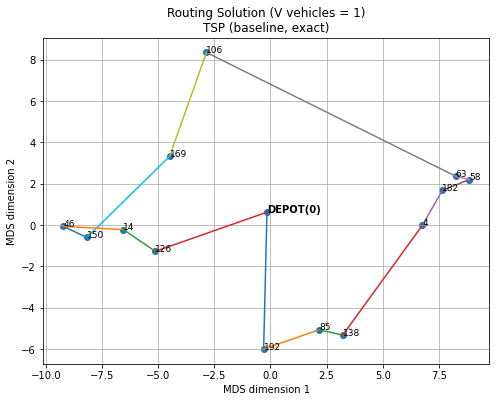

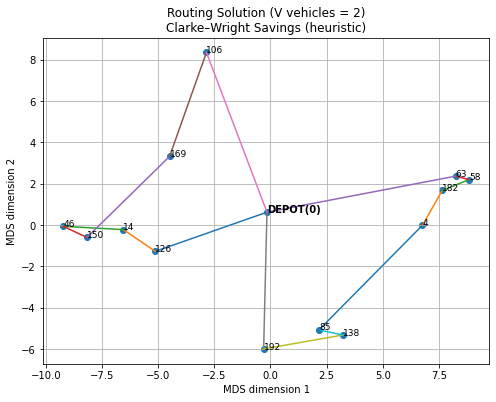

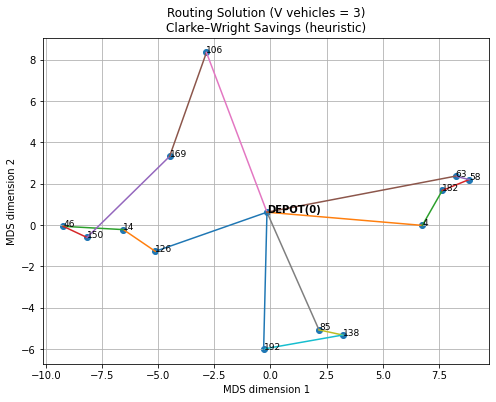

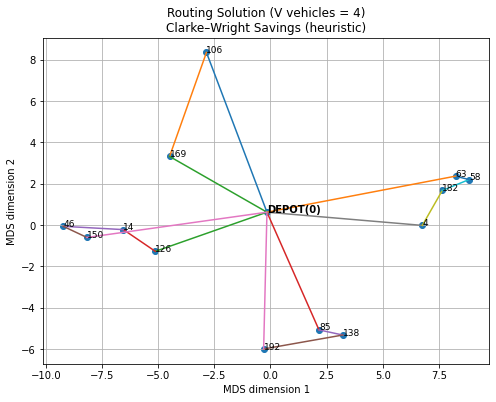


=== Route Details | V=1 | TSP (baseline, exact) ===
Vehicle 1:
  Customers: [192, 85, 138, 4, 182, 58, 63, 106, 169, 150, 46, 14, 126]
  Travel time (min): 135.85 | Service time (min): 285.61 | Total (min): 421.46
  Distance (km): 54.79

=== Route Details | V=2 | Clarke–Wright Savings (heuristic) ===
Vehicle 1:
  Customers: [126, 14, 46, 150, 169, 106]
  Travel time (min): 78.00 | Service time (min): 119.62 | Total (min): 197.62
  Distance (km): 29.82
Vehicle 2:
  Customers: [192, 138, 85, 4, 182, 58, 63]
  Travel time (min): 73.90 | Service time (min): 165.98 | Total (min): 239.88
  Distance (km): 30.55

=== Route Details | V=3 | Clarke–Wright Savings (heuristic) ===
Vehicle 1:
  Customers: [126, 14, 46, 150, 169, 106]
  Travel time (min): 78.00 | Service time (min): 119.62 | Total (min): 197.62
  Distance (km): 29.82
Vehicle 2:
  Customers: [85, 138, 192]
  Travel time (min): 46.74 | Service time (min): 57.60 | Total (min): 104.34
  Distance (km): 17.44
Vehicle 3:
  Customers: [4, 1

In [20]:
##################################################
# Clarke–Wright Savings VRP (depot-based, fixed V routes)
# Cost uses travel time (proposal: travel-time savings)
##################################################

S_max_per_vehicle = 460  # daily time capacity per vehicle

# --- service_time dict is required for route_total_time_min (travel + service) ---
service_time = {DEPOT: 0.0}
service_time.update(dict(zip(selected_df["request_id"], selected_df["service_time_min"])))

# selected customers only
customers = [c for c in selected_df["request_id"].tolist() if c != DEPOT]

DEPOT_NODE = DEPOT
depot_idx = node_to_idx[DEPOT_NODE]
cust_idx = [node_to_idx[c] for c in customers]  # customers are node-ids, convert to indices

def route_travel_time(route):
    return sum(time_mat[a, b] for a, b in zip(route[:-1], route[1:]))

def route_distance(route):
    return sum(dist_mat[a, b] for a, b in zip(route[:-1], route[1:]))

def route_service_time(route):
    cust_nodes = [idx_to_node[i] for i in route if idx_to_node[i] != DEPOT_NODE]
    return sum(service_time[n] for n in cust_nodes)

def compute_solution_metrics(routes_idx, S_max=460):
    route_metrics = []
    total_tt = 0.0
    total_km = 0.0

    for r in routes_idx:
        tt = route_travel_time(r)
        km = route_distance(r)
        st = route_service_time(r)
        total = tt + st
        cust_nodes = [idx_to_node[i] for i in r if idx_to_node[i] != DEPOT_NODE]

        route_metrics.append({
            "travel_time_min": tt,
            "distance_km": km,
            "service_time_min": st,
            "route_total_time_min": total,
            "customers": cust_nodes
        })

        total_tt += tt
        total_km += km

    max_route_total = max((rm["route_total_time_min"] for rm in route_metrics), default=0.0)
    feasible = (max_route_total <= S_max)

    return {
        "total_travel_time_min": total_tt,
        "total_distance_km": total_km,
        "max_route_total_time_min": max_route_total,
        "feasible_460min": feasible,
        "route_metrics": route_metrics
    }

def clarke_wright_vrp(V, cost_mat):
    """
    Clarke–Wright Savings heuristic:
    Start with routes [D,i,D], merge routes based on savings until #routes == V.
    Uses cost_mat (we'll pass time_mat).
    Returns routes as index lists (each starts/ends depot_idx).
    """
    routes = [[depot_idx, i, depot_idx] for i in cust_idx]

    def build_owner_map(routes_):
        owner = {}
        for ri, r in enumerate(routes_):
            for node in r[1:-1]:
                owner[node] = ri
        return owner

    savings = []
    for i in cust_idx:
        for j in cust_idx:
            if i == j:
                continue
            s = cost_mat[depot_idx, i] + cost_mat[depot_idx, j] - cost_mat[i, j]
            savings.append((s, i, j))
    savings.sort(reverse=True, key=lambda x: x[0])

    def is_start(route, node):
        return len(route) >= 3 and route[1] == node

    def is_end(route, node):
        return len(route) >= 3 and route[-2] == node

    for s, i, j in savings:
        if len(routes) <= V:
            break

        owner = build_owner_map(routes)
        if i not in owner or j not in owner:
            continue

        ri = owner[i]
        rj = owner[j]
        if ri == rj:
            continue

        R_i = routes[ri]
        R_j = routes[rj]
        merged = None

        if is_end(R_i, i) and is_start(R_j, j):
            merged = R_i[:-1] + R_j[1:]
        elif is_end(R_j, j) and is_start(R_i, i):
            merged = R_j[:-1] + R_i[1:]
        elif is_start(R_i, i) and is_start(R_j, j):
            R_i_rev = [R_i[0]] + list(reversed(R_i[1:-1])) + [R_i[-1]]
            if is_end(R_i_rev, i) and is_start(R_j, j):
                merged = R_i_rev[:-1] + R_j[1:]
        elif is_end(R_i, i) and is_end(R_j, j):
            R_j_rev = [R_j[0]] + list(reversed(R_j[1:-1])) + [R_j[-1]]
            if is_end(R_i, i) and is_start(R_j_rev, j):
                merged = R_i[:-1] + R_j_rev[1:]

        if merged is None:
            continue

        keep = min(ri, rj)
        drop = max(ri, rj)
        routes[keep] = merged
        routes.pop(drop)

    if len(routes) > V:
        routes = sorted(routes, key=lambda r: route_travel_time(r))[:V]

    return routes

##################################################
# Build solutions: V=1 TSP baseline + CW-VRP for V=2..4
##################################################

V_list = [1, 2, 3, 4]
solutions = []
rows = []

for V in V_list:

    # ---- V=1 baseline: use already-solved TSP tour from Part-1 ----
    if V == 1:
        if "tour_idx" not in globals():
            raise NameError("tour_idx not found. Run the TSP baseline (Part-1) first to create tour_idx.")
        routes_idx = [tour_idx]
        met = compute_solution_metrics(routes_idx, S_max=S_max_per_vehicle)
        sol = {
            "V": 1,
            "method": "TSP (baseline, exact)",
            "routes_idx": routes_idx,
            "routes": [[idx_to_node[i] for i in r] for r in routes_idx],
            **met
        }

    # ---- V>=2: Clarke–Wright Savings heuristic ----
    else:
        routes_idx = clarke_wright_vrp(V, cost_mat=time_mat)
        met = compute_solution_metrics(routes_idx, S_max=S_max_per_vehicle)
        sol = {
            "V": V,
            "method": "Clarke–Wright Savings (heuristic)",
            "routes_idx": routes_idx,
            "routes": [[idx_to_node[i] for i in r] for r in routes_idx],
            **met
        }

    solutions.append(sol)
    rows.append({
        "V": sol["V"],
        "method": sol["method"],
        "total_travel_time_min": round(sol["total_travel_time_min"], 2),
        "total_distance_km": round(sol["total_distance_km"], 2),
        "max_route_total_time_min": round(sol["max_route_total_time_min"], 2),
        "feasible_460min": sol["feasible_460min"],
    })

summary_cw_df = pd.DataFrame(rows)
print("\n=== Routing Comparison (Selected Set fixed, V vehicles) ===")
print(summary_cw_df.to_string(index=False))

##################################################
# Visualization: plot routes for each V
##################################################
for sol in solutions:
    V = sol["V"]
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:,0], coords[:,1])

    for i in range(n):
        node = idx_to_node[i]
        if node == DEPOT_NODE:
            plt.text(coords[i,0], coords[i,1], f"DEPOT({node})", fontweight="bold")
        else:
            plt.text(coords[i,0], coords[i,1], str(node), fontsize=9)

    for r in sol["routes_idx"]:
        for a, b in zip(r[:-1], r[1:]):
            x0, y0 = coords[a]
            x1, y1 = coords[b]
            plt.plot([x0, x1], [y0, y1])

    title = f"Routing Solution (V vehicles = {V})\n{sol['method']}"
    plt.title(title)
    plt.xlabel("MDS dimension 1")
    plt.ylabel("MDS dimension 2")
    plt.grid(True)
    plt.show()

#################################################
# Route details (per vehicle)
##################################################
for sol in solutions:
    print(f"\n=== Route Details | V={sol['V']} | {sol['method']} ===")
    for v, rm in enumerate(sol["route_metrics"], start=1):
        print(f"Vehicle {v}:")
        print(f"  Customers: {rm['customers']}")
        print(f"  Travel time (min): {rm['travel_time_min']:.2f} | Service time (min): {rm['service_time_min']:.2f} | Total (min): {rm['route_total_time_min']:.2f}")
        print(f"  Distance (km): {rm['distance_km']:.2f}")


### Reporting

In [21]:
cost_per_km = 0.35
S_max = S_max_per_vehicle  # 460

rows = []
for sol in solutions:
    route_totals = [rm["route_total_time_min"] for rm in sol["route_metrics"]]
    max_route_total = float(np.max(route_totals)) if route_totals else 0.0
    buffer_time = S_max - max_route_total

    total_distance = float(sol["total_distance_km"])
    travel_cost = total_distance * cost_per_km

    rows.append({
        "V": sol["V"],  # fleet size
        "method": sol["method"],
        "total_travel_time_min": round(float(sol["total_travel_time_min"]), 2),
        "total_distance_km": round(total_distance, 2),
        "travel_cost": round(travel_cost, 2),
        "max_route_total_time_min": round(max_route_total, 2),
        "buffer_time_min": round(buffer_time, 2),
        "feasible_460min": sol["feasible_460min"]
    })

kpi_df_simple = pd.DataFrame(rows).sort_values("V").reset_index(drop=True)

# İstersen distance_km veya feasible'ı bile çıkarabiliriz; ben şimdilik bıraktım.
print("\n=== Routing Evaluation KPIs (Simple) ===")
print(kpi_df_simple.to_string(index=False))



=== Routing Evaluation KPIs (Simple) ===
 V                            method  total_travel_time_min  total_distance_km  travel_cost  max_route_total_time_min  buffer_time_min  feasible_460min
 1             TSP (baseline, exact)                 135.85              54.79        19.18                    421.46            38.54             True
 2 Clarke–Wright Savings (heuristic)                 151.90              60.36        21.13                    239.88           220.12             True
 3 Clarke–Wright Savings (heuristic)                 168.13              66.62        23.32                    197.62           262.38             True
 4 Clarke–Wright Savings (heuristic)                 187.63              74.47        26.06                    151.77           308.23             True


## Fleet-Size Trade-off Table Summary

- In this analysis, the customer set is fixed (**K_selected = 13**). We only vary the **fleet size (V)** and generate routing plans using the distance/time matrix:
  - **V=1:** **Single-Vehicle TSP (Baseline)** with a depot-based tour  
  - **V>1:** **K-Vehicle VRP via Clarke–Wright Savings (Heuristic Extension)**
  This setup enables a clean comparison of single-vehicle versus multi-vehicle operations under the same selected customer set, and quantifies how routing outcomes change as fleet size increases.

- The evaluation focuses on two main dimensions:
  - **Route efficiency / cost side:** `total_distance_km`, `travel_cost`, `total_travel_time_min`
  - **Total operation time & workload (operational risk) side:** `max_route_total_time_min`, `buffer_time_min`

- The interpretation is driven by two opposing effects: as fleet size increases, **total distance/cost** tends to increase (more depot departures/returns), while the workload of the **busiest vehicle** decreases and **buffer** increases because the same workload is split across more vehicles.

### 2) Column definitions (simple and instructor-friendly)
- `total_travel_time_min`: The **total travel time** (in minutes) summed across all vehicles. This is a primary indicator of route efficiency.
- `total_distance_km`: Total kilometers traveled by all vehicles. It typically increases with V because each vehicle must start from and return to the depot (more depot round trips).
- `travel_cost`: A simple cost proxy = `total_distance_km × 0.35` (approximation of fuel/labor/operational cost).
- `max_route_total_time_min`: The (travel + service) total time of the **busiest vehicle**. This is the “worst-case workload” metric and indicates operational pressure under the 460-minute daily limit.
- `buffer_time_min`: Remaining slack within the 460-minute limit = `460 - max_route_total_time_min`. Larger buffer implies higher robustness to delays.

> Note (proposal alignment): `max_route_total_time_min` and `buffer_time_min` are used as the main workload/robustness indicators to keep the interpretation clear instead of adding more complex balance metrics.

### 3) Comment on Results
- **V=1 (TSP baseline):** Lowest total distance and cost (54.79 km, 19.18), hence the most economical option.  
  However, the busiest vehicle’s total time is high (max route total ≈ **421.46 min**) and the buffer is only **38.54 min**, meaning the schedule is relatively tight and more sensitive to delays.

- **V=2 (Clarke–Wright Savings):** Total distance/cost increases (60.36 km, 21.13), but the busiest vehicle workload drops sharply (max route total ≈ **239.88 min**) and buffer jumps to **220.12 min**.  
  This indicates a large robustness gain for a modest additional cost, mainly because the same 13-customer workload is split across two vehicles and the “bottleneck” vehicle becomes much less congested.

- **V=3 and V=4 (Clarke–Wright Savings):** Buffer continues to increase (**262.38 → 308.23 min**), while total distance/cost also rises (**66.62 → 74.47 km**, **23.32 → 26.06**).  
  The distance/cost increase is primarily caused by repeating depot departures/returns for additional vehicles. Beyond this point, the marginal robustness benefit becomes smaller while the added depot round-trip cost remains.

### 4) Interpreting the “optimal V” choice
The “optimal” choice depends on the decision objective and can be stated using two clear rules:

**(A) Cost-minimizing choice:**  
If the objective is to complete the workload with the lowest travel cost, **V=1** is preferred (minimum distance/cost), but it yields a tight schedule with low buffer.

**(B) Cost–robustness trade-off:**  
If the objective is to obtain a large buffer with a reasonable additional cost, **V=2** provides the strongest trade-off. From V=1 to V=2:
- Cost increases (**19.18 → 21.13**, +1.95)
- Buffer increases substantially (**38.54 → 220.12**, +181.58 min)
- The busiest vehicle’s total time drops significantly (**421.46 → 239.88 min**)

In practical terms, **V=1 is the cheapest**, while **V=2 is the best balance** between cost and operational robustness. Moving to V=3–4 further increases buffer but also increases total distance due to repeated depot round trips, with diminishing marginal gains.

### 5) Short conclusion 
- “With K_selected=13 fixed, increasing fleet size (V) generally increases total distance and travel cost because each additional vehicle must depart from and return to the depot. At the same time, splitting the same workload across more vehicles reduces the busiest vehicle’s total time and increases buffer, improving robustness to delays. These routing improvements (especially the larger buffer) can create operational room at the selection stage: under time/energy budget scenarios consistent with more available vehicles, the knapsack stage may be able to select and serve a larger number of requests.”

In [22]:
def knapsack_autoK(df, S_max_total, E_max_total,
                   id_col="request_id", value_col="value_score",
                   time_col="total_time_min", energy_col="kwh_needed",
                   verbose=False):
    ids = df[id_col].tolist()
    value  = dict(zip(df[id_col], df[value_col]))
    tproxy = dict(zip(df[id_col], df[time_col]))
    energy = dict(zip(df[id_col], df[energy_col]))

    m = gp.Model("knapsack_autoK")
    m.setParam("OutputFlag", 1 if verbose else 0)

    x = m.addVars(ids, vtype=GRB.BINARY, name="x")

    m.setObjective(gp.quicksum(value[i] * x[i] for i in ids), GRB.MAXIMIZE)
    m.addConstr(gp.quicksum(tproxy[i] * x[i] for i in ids) <= S_max_total, name="time_budget")
    m.addConstr(gp.quicksum(energy[i] * x[i] for i in ids) <= E_max_total, name="energy_budget")

    m.optimize()

    if m.SolCount == 0:
        return None

    sel = [i for i in ids if x[i].X > 0.5]
    total_value = sum(value[i] for i in sel)
    total_time  = sum(tproxy[i] for i in sel)
    total_kwh   = sum(energy[i] for i in sel)

    return {
        "selected_ids": set(sel),
        "selected_n": len(sel),
        "total_value_score": total_value,
        "total_time_proxy_min": total_time,
        "time_util": total_time / S_max_total,
        "total_energy_kwh": total_kwh,
        "energy_util": total_kwh / E_max_total
    }


##############################
# Run for multiple fleet sizes
###############################
V_list = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]  # proposal: vary K-vehicles (2–3) + baseline (1)

S_max_per_vehicle = 460
E_max_per_vehicle = 225

rows = []
sol_by_V = {}

for V in V_list:
    sol = knapsack_autoK(
        df,
        S_max_total = V * S_max_per_vehicle,
        E_max_total = V * E_max_per_vehicle,
        verbose=False
    )
    sol_by_V[V] = sol

    rows.append({
        "V": V,
        "selected_n (K*)": sol["selected_n"],
        "total_value_score": round(sol["total_value_score"], 2),
        "time_util": round(sol["time_util"], 4),
        "energy_util": round(sol["energy_util"], 4),
    })

knap_auto_df = pd.DataFrame(rows).sort_values("V").reset_index(drop=True)
print("\n=== Auto-K Knapsack vs Fleet Size ===")
print(knap_auto_df.to_string(index=False))



=== Auto-K Knapsack vs Fleet Size ===
 V  selected_n (K*)  total_value_score  time_util  energy_util
 1               13             208.92     0.9992       0.8436
 2               26             383.15     0.9995       0.8638
 3               37             542.78     0.9997       0.8481
 4               48             692.11     0.9996       0.8320
 5               59             833.66     0.9999       0.8284
 6               71             967.14     0.9999       0.8276
 7               82            1094.05     0.9998       0.8220
 8               94            1213.60     0.9999       0.8144
 9              104            1327.52     1.0000       0.8167
10              115            1436.17     1.0000       0.8148
11              126            1538.92     0.9999       0.8103
12              136            1632.14     0.9999       0.8080
13              146            1718.94     0.9995       0.8053
14              158            1799.88     0.9999       0.8034
15              

## Auto-K Knapsack vs K-Fleet Size (V) Evaluation

In this step, the knapsack model is run without fixing K (the number of selected requests). For each fleet size, the model maximizes the total `value_score` subject only to the time and energy budgets. Therefore, the number of selected requests is endogenously determined by the optimization and reported as `selected_n (K*)`.

### Column definitions
- `V`: Fleet size (number of vehicles). Total capacity scales with V: time budget `460×V`, energy budget `225×V`.
- `selected_n (K*)`: The number of requests selected by the model (optimal K).
- `total_value_score`: Total value score of the selected set (objective value).
- `time_util`: Time budget utilization.
- `energy_util`: Energy budget utilization.

- **`time_util` (time saturation):**  
  It shows what fraction of the total time capacity (`460×V` minutes) is consumed by the selected set.  
  When `time_util ≈ 1`, the time budget is nearly saturated, meaning **time is the binding constraint** in selection.

- **`energy_util` (energy saturation):**  
  It shows what fraction of the total energy capacity (`225×V` kWh) is used by the selected set.  
  Lower values indicate slack energy capacity, meaning energy is relatively less binding.

### Interpretation (cause–effect)
- **As V increases, more requests can be selected:**  
  The model selects 13 (V=1), 26 (V=2), and 37 (V=3) requests. This indicates that expanding fleet size increases total capacity, allowing the knapsack to select a larger feasible subset.
- **Total value increases with capacity:**  
  `total_value_score` increases from 208.92 → 383.15 → 542.78, meaning additional capacity enables the selection of more high-value requests.
- **Time is binding:**  
  Since `time_util` is ~1 for all scenarios, time is the dominant limiting resource in the selection stage.
- **Energy is relatively slack:**  
  With `energy_util` around 0.84–0.86, energy capacity is used but not fully saturated; once the time budget is filled, some energy capacity remains unused.

### Final takeaway
Overall, these results show that increasing fleet size expands the effective time/energy budgets and allows the knapsack-based selection stage to serve a larger number of requests under the same constraint structure, while increasing the total captured value (`value_score`).

# Marginal Value Analysis

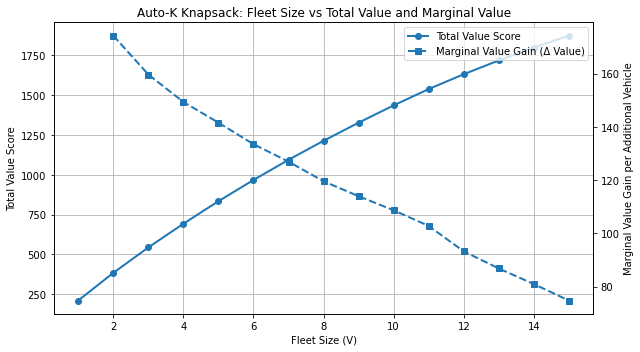

In [23]:
df_plot = knap_auto_df.copy()

df_plot["marginal_value_gain"] = df_plot["total_value_score"].diff()

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    df_plot["V"],
    df_plot["total_value_score"],
    marker="o",
    linewidth=2,
    label="Total Value Score"
)
ax1.set_xlabel("Fleet Size (V)")
ax1.set_ylabel("Total Value Score")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["V"],
    df_plot["marginal_value_gain"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Marginal Value Gain (Δ Value)"
)
ax2.set_ylabel("Marginal Value Gain per Additional Vehicle")

plt.title("Auto-K Knapsack: Fleet Size vs Total Value and Marginal Value")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.tight_layout()
plt.show()

## Auto-K Knapsack vs Fleet Size (V): Marginal Value Analysis

In this section, the **Auto-K knapsack results** are used to analyze how increasing the fleet
size (**V**) affects the total value generated from a **marginal benefit** perspective.
The goal is to quantitatively assess whether adding more vehicles continues to be economically
meaningful.

Under the Auto-K approach, the number of selected customers (**K**) is **not fixed in advance**.
Instead, for each fleet size, the knapsack model automatically selects the customer set that
maximizes the total `value_score` subject to the available time and energy capacities. This allows
the total value obtained at each **V** to be directly comparable.

### Key findings

- As the fleet size increases, both the number of selected requests and the total generated
  value increase.
- However, the **additional value contributed by each extra vehicle (marginal benefit)**
  decreases as the fleet grows.

### Marginal value computation

The marginal increase in total value is computed as:

$$
\Delta \text{Value}(V) = \text{Value}(V) - \text{Value}(V-1)
$$

This calculation reveals a clear **diminishing returns** pattern: the largest increase in total
value occurs when moving from **V = 1 to V = 2**, while subsequent vehicles provide progressively
smaller incremental contributions.

### Interpretation and managerial insight

An important observation is that the fleet size that maximizes marginal value (for this dataset,
approximately **V ≈ 2**) is **not universal**. This result depends on the specific customer value
distribution, time and energy requirements, and the geographic structure of the demand. For a
different customer pool, the marginal value curve—and thus the implied “optimal” fleet size—
may shift.

If, on a given day, customer values are relatively homogeneous, the sharp decline observed in
the marginal value curve provides a strong **decision-support signal**. Even if the firm owns a
larger fleet, this point can indicate how many vehicles should be actively deployed to achieve
a good balance between operational effort and value creation. Beyond this point, additional
vehicles can technically serve more requests, but the incremental value generated decreases
substantially.

Overall, the analysis demonstrates that the benefits of fleet expansion are not unbounded:
while increasing capacity allows more requests to be served, the value gained from each
additional vehicle grows at a decreasing rate. This provides a quantitative foundation for
evaluating not only fleet capacity, but also **effective daily fleet utilization**.
